In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from collections import defaultdict

In [7]:
# -------------------------
# FINAL STRATEGY CHART EXTRACTION
# -------------------------
# We now extract the “optimal” (greedy) action for each state in which a decision is made.
# For the final strategy chart we restrict ourselves to the first–move states.
# We build two tables:
#   - One for “hard” totals: player total from 5 to 20 (usable_ace==0)
#   - One for “soft” totals: player total from 13 to 20 (usable_ace==1)
#
# The dealer’s upcard is taken as 2–10 and Ace (represented by 1 in our environment).

actions_map = {0: "HIT", 1: "STK", 2: "DBL", 3: "SUR"}

# Build chart for hard totals
hard_data = {}
for player_total in range(5, 21):
    row = {}
    for dealer_card in [2,3,4,5,6,7,8,9,10,1]:  # note: dealer Ace is represented as 1; we will display it as "A"
        state = (player_total, dealer_card, 0, 1)  # first_move==True, usable_ace==False
        if state in Q:
            allowed = get_allowed_actions(state)
            action_values = Q[state]
            best_action = None
            best_value = -float('inf')
            for a in allowed:
                if action_values[a] > best_value:
                    best_value = action_values[a]
                    best_action = a
            col = "A" if dealer_card == 1 else str(dealer_card)
            row[col] = actions_map[best_action]
        else:
            col = "A" if dealer_card == 1 else str(dealer_card)
            row[col] = "-"
    hard_data[player_total] = row

df_hard = pd.DataFrame(hard_data).T.sort_index()

# Build chart for soft totals (player has a usable ace)
soft_data = {}
for player_total in range(13, 21):  # minimum soft total is 13 (Ace+2)
    row = {}
    for dealer_card in [2,3,4,5,6,7,8,9,10,1]:
        state = (player_total, dealer_card, 1, 1)  # first_move==True, usable_ace==True
        if state in Q:
            allowed = get_allowed_actions(state)
            action_values = Q[state]
            best_action = None
            best_value = -float('inf')
            for a in allowed:
                if action_values[a] > best_value:
                    best_value = action_values[a]
                    best_action = a
            col = "A" if dealer_card == 1 else str(dealer_card)
            row[col] = actions_map[best_action]
        else:
            col = "A" if dealer_card == 1 else str(dealer_card)
            row[col] = "-"
    soft_data[player_total] = row

df_soft = pd.DataFrame(soft_data).T.sort_index()

/tmp/ipykernel_265352/3673655409.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_hard_num = df_hard.replace(action_to_num)
/tmp/ipykernel_265352/3673655409.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_soft_num = df_soft.replace(action_to_num)


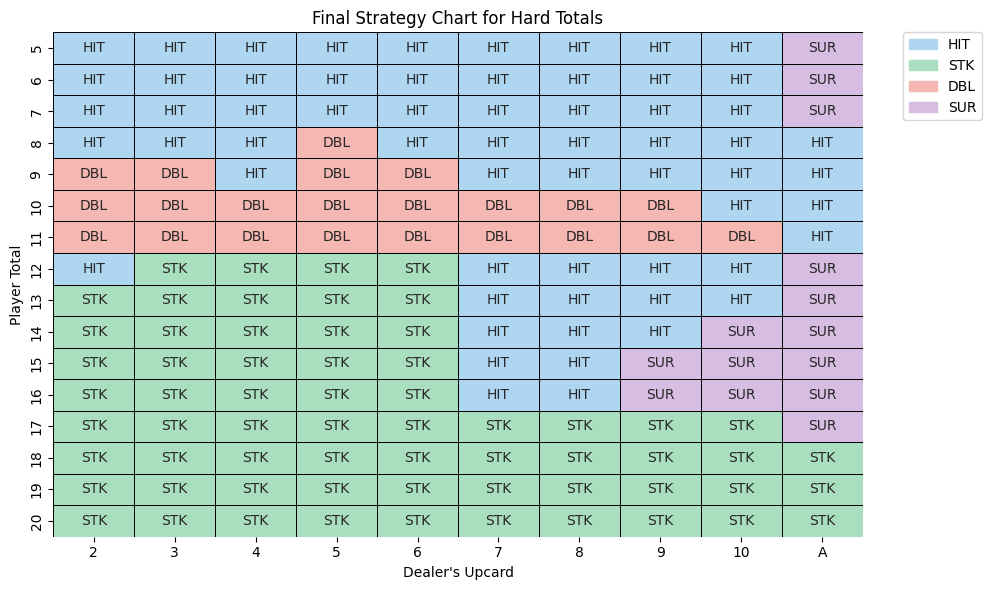

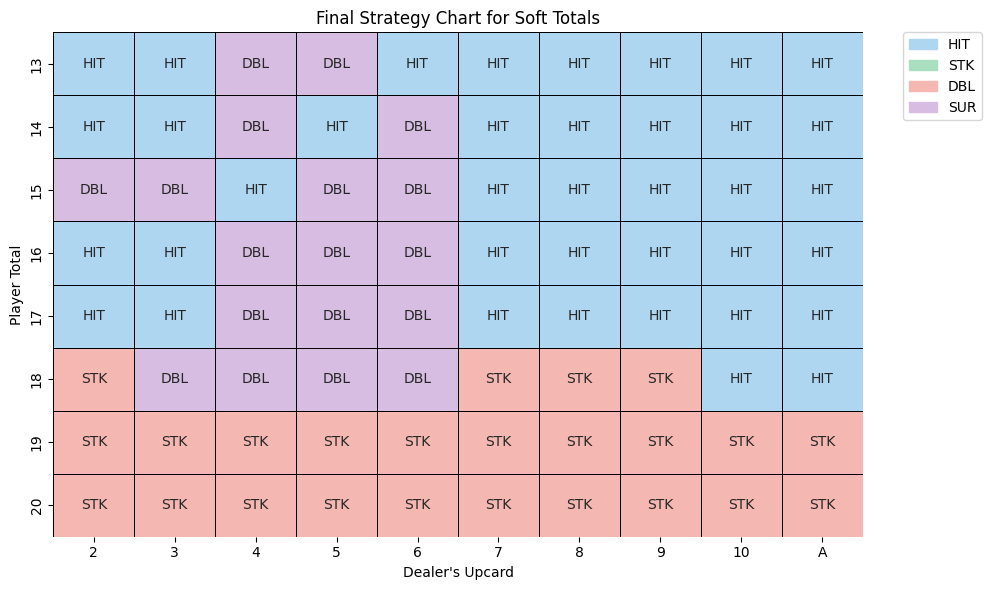

In [8]:
# -------------------------
# 4B. FINAL STRATEGY CHART VISUALISATION
# -------------------------
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# We'll use the same mapping of actions to names
actions_map = {0: "HIT", 1: "STK", 2: "DBL", 3: "SUR"}

# For visualization, we first map the action strings to numeric codes.
# We'll assign each action a unique number for color-coding.
action_to_num = {"HIT": 0, "STK": 1, "DBL": 2, "SUR": 3, "-": np.nan}

# Convert the strategy DataFrames (which contain action strings) to numeric DataFrames.
df_hard_num = df_hard.replace(action_to_num)
df_soft_num = df_soft.replace(action_to_num)

# Define a custom colormap with four distinct colors.
# (You can adjust these colors as desired.)
custom_cmap = ListedColormap(["#AED6F1", "#A9DFBF", "#F5B7B1", "#D7BDE2"])

# Create legend handles for the four actions.
legend_handles = [
    mpatches.Patch(color="#AED6F1", label="HIT"),
    mpatches.Patch(color="#A9DFBF", label="STK"),
    mpatches.Patch(color="#F5B7B1", label="DBL"),
    mpatches.Patch(color="#D7BDE2", label="SUR")
]

# -------------------------
# Plot for Hard Totals
# -------------------------
plt.figure(figsize=(10, 6))
ax = sns.heatmap(df_hard_num, 
                 annot=df_hard,       # annotate with the action strings
                 cmap=custom_cmap, 
                 cbar=False, 
                 linewidths=0.5, 
                 linecolor='black', 
                 fmt="")
ax.set_title("Final Strategy Chart for Hard Totals")
ax.set_ylabel("Player Total")
ax.set_xlabel("Dealer's Upcard")
# Add the legend outside the heatmap
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

# -------------------------
# Plot for Soft Totals
# -------------------------
plt.figure(figsize=(10, 6))
ax2 = sns.heatmap(df_soft_num, 
                  annot=df_soft,       # annotate with the action strings
                  cmap=custom_cmap, 
                  cbar=False, 
                  linewidths=0.5, 
                  linecolor='black', 
                  fmt="")
ax2.set_title("Final Strategy Chart for Soft Totals")
ax2.set_ylabel("Player Total")
ax2.set_xlabel("Dealer's Upcard")
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()